# **Évolution du modèle de FakyFake**

Nous, équipe de FakyFake sommes partis d'un constat simple, à l'oeil humain il nous est impossible de distinguer les visages générés par IA depuis ces derniers mois.

Nous avons donc décidé de créer notre propre modèle afin de régler ce problème

# PREMIER JET

****

Nous nous sommes renseignés sur plusieurs modèles de traitement d'image, tous utilisant tensorflow, pour sa qualité pour de l'exécution de tâches complexes et ces différents modèles déjà créés dans ce domaine comme [MobileNet](https://keras.io/api/applications/mobilenet/), ou encore [EfficentDet](https://github.com/xuannianz/EfficientDet)

Il y a évidemment plus de modèles mais nous y reviendrons un peu plus tard car nous avons eu pas mal d'inspiration de code notamment sur la création du modèle.

****
En plus de tensorflow, étant la librairie "parente" nous utilisons et importons keras afin de pouvoir traiter nos tâches complexes de manière beaucoup plus simplifiées et nous donnant des outils déjà préconstruits.

Nous importons également kagglehub, qui va nous permettre d'importer nos sets de données que nous allons exploiter pour le training et le test.

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import kagglehub

L'importation se fait simplement via l'API fournie par Kagglehub permettant de cibler le répertoire nous intéressant sans avoir à s'encombrer des fichiers, nous sommes néanmoins sur des datasets assez lourds comme on peut le voir ci-dessous



In [ ]:
# Chemins des données
REAL_FACES_DIR = kagglehub.dataset_download("tunguz/70000-real-faces-1")
FAKE_FACES_DIR = kagglehub.dataset_download("tunguz/1-million-fake-faces")

Downloading from https://www.kaggle.com/api/v1/datasets/download/tunguz/70000-real-faces-1?dataset_version_number=10...
100%|██████████| 19.1G/19.1G [16:37<00:00, 20.5MB/s]
 ****
Downloading from https://www.kaggle.com/api/v1/datasets/download/tunguz/1-million-fake-faces?dataset_version_number=3...
 39%|███▉      | 6.45G/16.5G [05:40<09:16, 19.5MB/s]

  ****

  *Montrés ici à motif d'exemples mais avec les vraies valeurs pris lors d'un vrai run, ce dernier n'étant pas effectif*

****

Voici la fonction principale permettant de normaliser et charger nos images provenant de nos datasets : Elle fonctionne comme ceci

Nous venons charger nos images à partir de répertoires spécifiques et leur attribue un label (ici nous pouvons voir 0 ou 1).

La fonction load_images parcourt récursivement le dossier donné.
Elle cherche des fichiers d'images avec des extensions comme .png, .jpg, ou .jpeg (afin de normaliser nos formats pour éviter des injections d'autres formats).
Chaque image est redimensionnée à 128x128 pour correspondre à une norme, convertie en tableau numérique, puis ajoutée à une liste.

Un label correspondant au type d'image (réel ou faux) est ajouté à une autre liste.

Les erreurs de chargement d'image sont affichées pour avoir un debug utile en cas de crash.

In [ ]:
## Ajouté à titre de documentation postérieure : 1ère version - CHANGEMENTS DANS LA SUITE DU NB ##

# Charger les images et leurs labels
def load_images(directory, label):
    images = []
    labels = []
    for root, _, files in os.walk(directory):  # Traverse directories recursively
        for filename in files:
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):  # Check for image extensions
                filepath = os.path.join(root, filename)
                try:
                    image = tf.keras.preprocessing.image.load_img(filepath, target_size=(128, 128))
                    image = tf.keras.preprocessing.image.img_to_array(image)
                    images.append(image)
                    labels.append(label)
                except Exception as e:
                    print(f"Error loading image {filepath}: {e}")
    return images, labels

# Charger les données
real_images, real_labels = load_images(REAL_FACES_DIR, 0)
fake_images, fake_labels = load_images(FAKE_FACES_DIR, 1)

Cette fonction, que vous voyez ici, était à son premier jet, au fil des modèles, elle subira énormément de changements, car il n'y a ici aucune limite par rapport au nombre d'images chargées, ce qui provoquera lors du premier jet un temps d'exécution beaucoup trop long pour nos machines, rendant l'initialisation du modèle impossible.

****
****

Les méthodes ci-dessous permettent de combiner l'ensemble de nos données afin de pouvoir les utiliser convenablement sur un modèle de deep-learning, donc globalement combiner les images en une liste de tableau d'élements de floats qu'on convertit en un énorme tableau.

De même pour les labels, mais étant des 0 et des 1 aucun post-processing n'est nécessaire sur leur valeur.

****

Nous venons ensuite diviser les données de manière aléatoire entre données d'entraînement, de validation et données de test.

Dans un premier temps nous prenons 70% de données pour l'entraînement, et 30% pour le test/validation (Représenté par le X_temp et Y_temp)

En dessous, nous séparons nos données X_temp et Y_temp en données de test et de validation, séparant à 50% de nos derniers 30% de données, donc nous arrivons à une répartition de

- 70% Données d'entraînement
- 15% Données de validation
- 15% Données de test

Nous avions assez de données pour séparer de manière arbitraire ces données de cette manière, préférant ainsi donner à l'entraînement une importance suffisante mais ne risquant pas de sur-apprentissage même si nous jouions avec la limite.

In [ ]:
## Ajouté à titre de documentation postérieure : 1ère version - CHANGEMENTS DANS LA SUITE DU NB ##

# Combiner les images et les labels
images = np.array(real_images + fake_images, dtype="float32")
labels = np.array(real_labels + fake_labels)

# Diviser les données
X_train, X_temp, y_train, y_temp = train_test_split(images, labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


****
****

Par la suite nous allons augmenter nos données, qui peut paraître assez ironique si on considère que nos temps d'exécutions étaient déjà longs mais en réalité il s'agit surtout de renforcement de nos données de test

En effet, nous allons prendre nos données de nos sets de tests et appliquer es rotations ou des altérations de manière aléatoire à certaine de nos images afin de créer des images plus "réalistes" et moins représentant un shooting photo.

Nous prenons alors le risque d'augmenter la quantité de données, même sur un petit volume, afin de renforcer la solidité de nos entraînements.

In [ ]:
# Augmentation des données

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)
train_generator = datagen.flow(X_train, y_train, batch_size=32)

****
****

Ici vient la partie charnière de notre NoteBook, l'élaboration du modèle. Ici vous pouvez voir notre première version, qu'on va vous détailler dans les étapes à venir

Ce modèle est construit sous le format d'un "[CNN](https://victorzhou.com/blog/keras-cnn-tutorial/)" c'est à dire "Convolutional Neural Network" soit traduit en Réseau de Neurones Convolutifs, signifiant que ce réseau va appliquer une sorte de petit filtre à notre image afin d'en extraire des caractéristiques lui permettant de ce décider

C'est un modèle qui est très efficace pour prendre des décisions notamment sur un format Vrai/Faux et c'est un modèle qu'on a décidé de garder tout au long de notre création de modèle.

------------

Cependant sur notre premier jet nous avions décidé de l'élaborer comme ceci

- `Conv2D` sert à appliquer des filtres pour en tirer les caractéristiques (la convolution), nous l'avons séparé en trois étapes toutes de manière incrémentale en terme de nombres de filtres séparés par un MaxPooling afin de chercher des caractéristiques beaucoup plus complexes et plus "cachées"
- `MaxPooling` sert à réduire la taille de l'image, ici à un facteur "2 | 2" par rapport à notre image précédente afin de faire ressortir nos caractéristiques dominantes dans l'image
- `Flatten` On vient "applatir" les couches qu'on vient de créer (nos couches convolutives" pour les rendre sur un même plan que nos couches principales de l'image étudiée
- `Dense` Nous rajoutons des chemins neuronaux pour assimiler de manière plus efficace les caractéristiques les plus complexes (**ReLu**) OU les caractéristiques binaires (0 | 1) de nos labels (**Sigmoid**) .
- `Dropout` Pour éviter le surapprentissage de caractéristiques moins "dominantes" nous désactivons une partie des neurones, ici 50% afin de ne pas se retrouver avec une IA associant une image à une erreur au lieu des caractéristiques.

Nous utilisons enfin l'optimizer "Adam", qui, comparé à ses concurrents [RMSProp](https://keras.io/api/optimizers/rmsprop/) ou encore [Adagrad](https://keras.io/api/optimizers/adagrad/), est beaucoup plus efficace pour l'ajustement des taux d'apprentissages, donc plus efficace pour les tâches complexes, mais également une certaine robustesse pour les très grandes données et donc de ce fait les données lourdes.

Ensuite nous utilisons le binary_crossentropy très efficace pour le traitement de données binaires pour nos données perdues et enfin notre métrique principale se repose sur l'accuracy, sa capacité à comprendre les images vraies des images fausses.




In [ ]:
## Ajouté à titre de documentation postérieure : 1ère version - CHANGEMENTS DANS LA SUITE DU NB ##

# Construire le modèle

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

****

Définition des callbacks de manière très simple :

- Définition d'un arrêt prématuré si on remarque que le valeur "val_loss" (définissant la perte moyenne des données sur le dataset de validation) ne s'améliore pas à 5 occurences de suite, signifiant une stagnation de notre modèle
- Création d'un Checkpoint "base_model.keras" à chaque itération des Epoch (qu'on verra par la suite) pour garder une trace de l'amélioration de notre modèle au cas où celui-ci venait à s'arrêter prématurément

In [ ]:
## Ajouté à titre de documentation postérieure : 1ère version - CHANGEMENTS DANS LA SUITE DU NB ##

# Définir les callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('base_model.keras', save_best_only=True)
]

Entraînement du modèle suivant une philosophie claire, création du dataset de train avec les images altérées ou rotationnées de tout à l'heure, nos données de validation représentant 15% du dataset initial, 20 répétitions des mêmes images afin de consolider l'apprentissage et l'application des callbacks

Et enfin à la fin de l'entraînement, processus de test des données et sauvegarde du modèle

In [ ]:
## Ajouté à titre de documentation postérieure : 1ère version - CHANGEMENTS DANS LA SUITE DU NB ##

# Entraîner le modèle
history = model.fit(
    train_generator,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=callbacks
)

# Évaluation et sauvegarde
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
model.save("final_model.keras")



Il faut savoir que lors de la première itération de ce modèle nous n'avons pas pu aller à cette étape, car comme dit précédemment le chargement des images, contenant un nombre de données infiniment trop grand, nous prenait plus d'une demi journée, et donc nous avons dû l'arrêter avant de voir l'efficacité de la première occurence.

# AMÉLIORATIONS

****

## LOAD IMAGES

La première fonction ayant été cause de problèmes majeurs aura été celle-ci, proposant un temps de chargement trop long, presque irréalisable avec la qualité de nos machines et même celles fournies par Colab.





In [ ]:
## SECONDE VERSION ##

# Charger les images et leurs labels
def load_images(directory, label, max_images=None):
    images = []
    labels = []
    for root, _, files in os.walk(directory):  # Traverse directories recursively
        for filename in files:
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):  # Check for image extensions
                filepath = os.path.join(root, filename)
                try:
                    image = tf.keras.preprocessing.image.load_img(filepath, target_size=(128, 128))
                    image = tf.keras.preprocessing.image.img_to_array(image)
                    images.append(image)
                    labels.append(label)
                except Exception as e:
                    print(f"Error loading image {filepath}: {e}")
    # Sélectionner un sous-échantillon si max_images est défini
    if max_images and len(images) > max_images:
        selected_indices = random.sample(range(len(images)), max_images)
        images = [images[i] for i in selected_indices]
        labels = [labels[i] for i in selected_indices]
    return images, labels

# Charger les données avec une limite de 35 images par classe
real_images, real_labels = load_images(REAL_FACES_DIR, 0, max_images=35)
fake_images, fake_labels = load_images(FAKE_FACES_DIR, 1, max_images=35)

Ici vous pouvez voir que nous avons réussi à apprendre de nos erreurs. En limitant le nombre d'images maximales par 35 nous avions réussir à accélérer drastiquement le temps de traitement.

Du moins nous pensions, et puis nous avons fait run le projet et puis, et bien non en fait. Ce que nous faisions était caduque avant même d'être testé. Nous chargions toujours la même quantité d'images. Mais nous faisions un tri à la fin, donc ce n'était évidemment pas viable.

****

In [ ]:
## TROISIÈME VERSION ##

# Charger les images et leurs labels
def load_images(directory, label, max_images=None):
    images = []
    labels = []

    # Obtenir la liste de tous les fichiers d'image dans le répertoire
    all_files = [
        os.path.join(root, filename)
        for root, _, files in os.walk(directory)
        for filename in files
        if filename.lower().endswith(('.png', '.jpg', '.jpeg'))  # Vérifier les extensions
    ]

    # Sélectionner aléatoirement max_images fichiers si max_images est défini
    if max_images and len(all_files) > max_images:
        all_files = random.sample(all_files, max_images)

    # Charger les fichiers sélectionnés
    for filepath in all_files:
        try:
            image = tf.keras.preprocessing.image.load_img(filepath, target_size=(128, 128))
            image = tf.keras.preprocessing.image.img_to_array(image)
            images.append(image)
            labels.append(label)
        except Exception as e:
            print(f"Error loading image {filepath}: {e}")

    return images, labels


# Charger les données avec une limite de X images par classe
real_images, real_labels = load_images(REAL_FACES_DIR, label=0, max_images=2000)
fake_images, fake_labels = load_images(FAKE_FACES_DIR, label=1, max_images=2000)

Ici nous voilà avec une solution beaucoup plus agréable, cette fois nous allons pas choisir nos images à postériori de les avoir charger, mais nous allons sélectionner aléatoirement dans nos fichiers, beaucoup moins couteux et surtout beaucoup plus efficace. Ici pour un premier sample nous avions 2000 images.

Et enfin, nous avons pu lancer notre premier modèle.

In [ ]:
## VERSION FINALE ##

# Charger les données
def load_images(directory, label, max_images=None):
    images, labels = [], []
    all_files = [
        os.path.join(root, filename)
        for root, _, files in os.walk(directory)
        for filename in files
        if filename.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]
    if max_images:
        all_files = random.sample(all_files, min(len(all_files), max_images))
    for filepath in all_files:
        try:
            img = load_img(filepath, target_size=(128, 128))
            img_array = img_to_array(img)
            images.append(img_array)
            labels.append(label)
        except Exception as e:
            print(f"Erreur lors du chargement de l'image {filepath}: {e}")
    return images, labels

La version finale est très simple, il s'agit de la version d'au dessus mais de manière refactorisée et optimisée, le temps gagné n'est pas aussi important que la version précédente mais il s'agit toujours d'une amélioration notable.

## AMÉLIORATION DU MODÈLE ET DE SON ENTRAINEMENT

Alors oui, nous avons pu lancer notre modèle et de ce fait nous avons pu nous rendre compte de la limite d'un modèle pouvant partir de 0, les premiers runs du modèle fait main atteignaient vite leurs limites :

Voici les premières metrics qu'on a pu avoir

- Total Accuracy (données de test) : 66%
- Accuracy Moyenne (données de train) : 70%

Malgré ce qu'on craignait et les mesures qu'on a pu prendre pour éviter le surapprentissage, les résultats semblaient montrer un léger sur-apprentissage qui venait dérégler nos données de test. Certes le modèle restait mieux que le hasard, mais malgré quelques améliorations qu'il ne serait pas forcément judicieux de montrer ici mais comprenant par exemple l'augmentation du `Dropout` du modèle à 70%, on peinait à améliorer ces résultats.

Nous avons donc pris des mesures assez drastiques.

****

À défaut de partir d'un modèle "vide", nous avons pris la décision de partir sur un modèle pré-entrainé.

Nous avons pris la décision de partir sur la famille EfficientNetB, prenant le premier modèle EfficientNetB0, pourquoi cela ? Car c'est le plus rapide par rapport à ses concurrents et également le moins lourd et le moins complexe dans l'accomplissement de ses tâches. Le double avantage de partir avec ce modèle résidait dans la facilité de l'implémentation, la rapidité d'exécution et surtout l'avantage d'un modèle préentrainé c'est qu'il a un set de données d'images assez conséquent.

EfficientNetB0 est un modèle de réseau de neurones convolutifs (CNN) conçu pour la classification d'images. Il fait partie de la famille des modèles EfficientNet, qui optimisent simultanément trois dimensions des réseaux neuronaux : la profondeur, la largeur et la résolution des images, grâce à une méthode appelée compound scaling. EfficientNetB0 utilise une architecture basée sur des blocs MBConv (Mobile Inverted Bottleneck Convolution). Ce modèle est à la fois performant et efficace, offrant un excellent compromis entre précision et coût de calcul.

Pour expliquer le nouveau fonctionnement :

- Nous chargeons notre nouveau modèle EfficientNetB0, en lui implémentant des données via ImageNet qui est un grand dataset d'images, on enlève les couches supérieures avec le `include_top=false` afin de pouvoir implémenter nos propres couches de sorties, et nous spécifions la forme d'entrée des images, soit du 128 par 128 et 3 canaux de représentation de couleurs (RGB ici)

- Nous bloquons l'entraînement de base du modèle pré-entraîné pour garder les précédentes couches que le modèle a pu apprendre via ImageNet et éviter de se baser sur des couches précédentes pouvant altérer l'apprentissage des nouvelles couches.

- Nous retrouvons certaines caractéristiques de notre ancien modèle, dont les `Dense`via reLU ou Sigmoid pour les relations complexes, et le `Dropout`pour le surapprentissage, mais nous retrouvons un nouveau paramètre : `GlobalAveragePooling2D`qui nous sert à simplifier l'identification de chaque caractéristiques, sans avoir à plonger totalement dans toutes pour avoir une idée globale des caractéristiques qui lui permettra de choisir entre le vrai du faux. Il s'agit globalement d'une "moyenne" des pixels sans rentrer dans les détails de chaque pixel pour optimiser le temps passé et drastiquement le réduire. On parle de réduire la dimensionalité de chaque image.

- Nous retrouvons exactement le même compilateur, ne l'ayant pas jugé comme étant le problème de nos résultats précédents.



In [ ]:
## DEUXIÈME VERSION ##

# Charger EfficientNetB0 pré-entraîné
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Geler les couches du modèle de base
base_model.trainable = False

# Construire le modèle
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compiler le modèle
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Mais lors de l'instauration de ce nouveau modèle, une idée nous est venue en tête. Alors certes nous bloquons l'ancien modèle pour la première partie de l'entraînement, augmentant drastiquement le nombre d'epochs également pour avoir des résultats plus fiables même si un peu plus longs.

Pourquoi ne pas rajouter une dernière phase à notre entraînement ? Une fois que nous avons un modèle satisfaisant, pourquoi ne pas le sublimer ?

C'est alors que nous avons eu l'idée de faire du [Fine-Tuning](https://keras.io/guides/transfer_learning/) qui se fait très souvent pour des modèles basés sur du pré-entrainé

Il s'agit globalement de réactiver l'entraînement des couches inférieures du modèle après le premier entrainement des couches supérieures (extérieures au modèle pré-entrainé) afin de consolider les données apprises peu avant en les partageant avec ses données d'ImageNet. Cela permet à la fois de renforcer notre modèle, mais également de limiter encore une fois les risques de sur-apprentissage qui est dans notre cas le pire poison qu'on pourrait avoir.

Alors l'idée n'était évidemment pas de débloquer toutes les couches, mais seulement celles les plus "hautes" afin de ne pas non plus totalement dérégler le modèle mais vraiment le marquer comme une empreinte, pour le spécialiser.

Il faut savoir que pour le fine-tuning nous réduisons la vitesse d'apprentissage, car il s'agit majoritairmeent d'une tâche de renforcement.

In [ ]:
# Entraîner le modèle
history = model.fit(
    train_generator,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=callbacks
)

# Débloquer et fine-tuner certaines couches du modèle de base
base_model.trainable = True
fine_tune_at = len(base_model.layers) // 2  # Fine-tuner les couches supérieures
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Recompiler avec un learning rate réduit
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Continuer l'entraînement
history_fine_tune = model.fit(
    train_generator,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=callbacks
)

Et enfin, nous avons pu observer de bons résultats



In [ ]:
SAMPLE Entraînement -

Epoch 10/50
88/88 [==============================] - 99s 1s/step - loss: 0.4797 - accuracy: 0.7668 - val_loss: 0.5853 - val_accuracy: 0.7267
Epoch 11/50
88/88 [==============================] - 99s 1s/step - loss: 0.4698 - accuracy: 0.7764 - val_loss: 0.5515 - val_accuracy: 0.7400
Epoch 12/50
88/88 [==============================] - 99s 1s/step - loss: 0.4539 - accuracy: 0.7893 - val_loss: 0.5858 - val_accuracy: 0.7167


SAMPLE FineTuning

Epoch 12/20
88/88 [==============================] - 163s 2s/step - loss: 0.1969 - accuracy: 0.9179 - val_loss: 0.4335 - val_accuracy: 0.8400
Epoch 13/20
88/88 [==============================] - 163s 2s/step - loss: 0.1840 - accuracy: 0.9293 - val_loss: 0.4390 - val_accuracy: 0.8433
Epoch 14/20
88/88 [==============================] - 164s 2s/step - loss: 0.1756 - accuracy: 0.9264 - val_loss: 0.4355 - val_accuracy: 0.8417
Epoch 15/20
88/88 [==============================] - 163s 2s/step - loss: 0.1555 - accuracy: 0.9375 - val_loss: 0.4652 - val_accuracy: 0.8583
Epoch 16/20
88/88 [==============================] - 165s 2s/step - loss: 0.1401 - accuracy: 0.9454 - val_loss: 0.4571 - val_accuracy: 0.8383

Test Accuracy: 82.83%

Un résultat satisfaisant, mais pas assez, 82% c'est déjà beaucoup mieux, mais nous savions que nous pouvions allez bien plus haut. Et surtout côté intéressant

- Nos données de training étaient à 94% sur l'avant dernière occurence
- Nos données de validation étaient à 85 % sur l'avant dernière occurence
- L'accuracy de test était à 82%

Et bien, on peut observer qu'on a un surapprentissage encore assez important, mais en réalité, montant dans les pourcentages, et surtout sur "peu" de répétitions on s'inquiète moins que sur les données ci-dessus.

Ce qui est un peu plus inquiétant cependant c'est la quantité de données perdues sur les données de validation, qui peut avoir un impact très négatif sur l'analyse de nos images

Nous reviendrons au modèle plus tard, car nous allons parler d'une grosse évolution majeure, mais il faut se dire que ce modèle restera amélioré sur des petits points, petit à petit mais sur d'autres points jusqu'à un certain point.

Un changement notable cependant a été fait sur les callbacks avec l'ajout d'une catégorie `ReduceLROnPlateau` qui vient réduire le Learning Rate de notre application si nous perdons trop de données de validation pour palier à notre écart trop grand


In [ ]:
## VERSION FINALE DES CALLBACKS ##

# Définir les callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint(model_path, save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
]


Nous observons alors les données suivantes,

- Une baisse assez importante de la val_loss
- Une amélioration assez correcte de la val_accuracy

En effet, réduire la val_loss permet de laisser plus temps au modèle d'évaluer des données et donner son pronostic, la réduction du learning_rate le fait moins "réfléchir" par rapport à cela également et donc corrige le tir.

- On observe alors une augmentation de la Test Accuracy à 89.40%, égale à la val_accuracy ce qui est très rassurant.

Proposant toujours un écart avec l'accuracy globale, donc surlignant le phénomène de sur-apprentissage mais dont nous n'avons pas forcément la vision dessus pour l'instant.


In [ ]:

SAMPLE Entraînement -

Epoch 10/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 41s 145ms/step - accuracy: 0.7605 - loss: 0.5006 - val_accuracy: 0.7720 - val_loss: 0.4715 - learning_rate: 0.0010
Epoch 11/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 30s 134ms/step - accuracy: 0.7483 - loss: 0.5134 - val_accuracy: 0.7680 - val_loss: 0.4773 - learning_rate: 0.0010
Epoch 12/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 41s 135ms/step - accuracy: 0.7608 - loss: 0.4929 - val_accuracy: 0.7560 - val_loss: 0.4873 - learning_rate: 0.0010
Epoch 13/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 41s 136ms/step - accuracy: 0.7436 - loss: 0.5087 - val_accuracy: 0.7633 - val_loss: 0.4872 - learning_rate: 0.0010
Epoch 14/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 42s 141ms/step - accuracy: 0.7632 - loss: 0.4896 - val_accuracy: 0.7607 - val_loss: 0.4848 - learning_rate: 2.0000e-04
Epoch 15/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 46s 153ms/step - accuracy: 0.7724 - loss: 0.4709 - val_accuracy: 0.7640 - val_loss: 0.4759 - learning_rate: 2.0000e-04

Sample Fine-Tuning

Epoch 15/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 33s 143ms/step - accuracy: 0.9291 - loss: 0.1692 - val_accuracy: 0.8800 - val_loss: 0.3210 - learning_rate: 2.0000e-05
Epoch 16/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 41s 147ms/step - accuracy: 0.9395 - loss: 0.1465 - val_accuracy: 0.8940 - val_loss: 0.2930 - learning_rate: 2.0000e-05
Epoch 17/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 33s 146ms/step - accuracy: 0.9376 - loss: 0.1516 - val_accuracy: 0.8860 - val_loss: 0.3080 - learning_rate: 2.0000e-05
Epoch 18/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 42s 153ms/step - accuracy: 0.9452 - loss: 0.1363 - val_accuracy: 0.8927 - val_loss: 0.3078 - learning_rate: 2.0000e-05
Epoch 19/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 32s 143ms/step - accuracy: 0.9578 - loss: 0.1191 - val_accuracy: 0.8953 - val_loss: 0.3030 - learning_rate: 2.0000e-05
Epoch 20/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 32s 143ms/step - accuracy: 0.9460 - loss: 0.1312 - val_accuracy: 0.8940 - val_loss: 0.3005 - learning_rate: 4.0000e-06
2025/01/07 12:35:15 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during tensorflow autologging: Changing param values is not allowed. Param with key='epochs' was already logged with value='50' for run ID='23ebf40bdcd544f2890b2a51cd8029b3'. Attempted logging new value '20'.
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8917 - loss: 0.2843
Test Accuracy: 89.40%

## TRAITEMENT DES IMAGES

En réalité la majorité des changements par la suite se feront par rapport au traitement des images, notamment pour s'adapter au modèle pré-entrainé.

Dans une deuxième version, nous avons décidé tout simplement d'ajouter la version de traitement des images que nous fournissait EfficientNet, c'est une version qui nous as tout de suite amélioré les résultats, et notamment avec la vision qu'on pouvait avoir du [code](https://www.tensorflow.org/api_docs/python/tf/keras/applications/resnet/preprocess_input) qu'on a scruté, ça nous semblait très correcte, nous avons évidemment pensé à le changer mais ça aurait été du temps alloué que nous n'avions pas forcément.

In [ ]:
## DEUXIÈME VERSION ##
from tensorflow.keras.applications.efficientnet import preprocess_input

# Prétraiter pour EfficientNet
images = preprocess_input(images)


Pour la version finale, au lieu de le faire à la main nous avons décidé de tout restructurer dans une même méthode afin de ne pas se perdre, il s'agit ici juste de l'optimisation de code mais il semblait important de le préciser pour montrer une évolution dans notre manière de structurer notre modèle.

In [ ]:
## VERSION FINALE ##

def preprocess_data(real_dir, fake_dir, max_images=5000):
    real_images, real_labels = load_images(real_dir, label=0, max_images=max_images)
    fake_images, fake_labels = load_images(fake_dir, label=1, max_images=max_images)
    images = np.array(real_images + fake_images, dtype="float32")
    labels = np.array(real_labels + fake_labels)
    images = preprocess_input(images)
    return images, labels

# AJOUTS

Nous avons procédé à plusieurs ajouts au fur et à mesure du développement de notre modèle, nous avons donc décidé de vous les lister de manière non exhaustive, dans leur version finale (ou intermédiaire si cela vaut le coup) ci-dessous

## Visualisation

Nous avons jugé cohérent de rajouter de la visualisation à nos données, nous avions des prints mais ce n'était évidemment pas assez de ce fait nous avons essayé deux choses

Dans un premier temps nous avons essayé d'ajouter ML-FLOW, qui nous aurait donc généré un fichier avec les données de nos Epochs à chaque itération

In [ ]:
import mlflow
import mlflow.tensorflow

# Initialisation de MLflow
mlflow.set_experiment("Face_Classification")
mlflow.tensorflow.autolog()

----------------- # Étape différente

parameters = {
    "batch_size": 128,
    "epochs": 50,
    "optimizer": "adam",
    "loss": "binary_crossentropy",
    "validation_split": 0.1,
}

experiment.log_parameters(parameters)

# Création du modèle
def build_model():
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
    base_model.trainable = False

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer=parameters["optimizer"], loss=parameters["loss"], metrics=['accuracy'])
    return model


----------------- # Étape différente

# Entraîner le modèle
with mlflow.start_run():
    model = build_model()
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ModelCheckpoint('best_model_efficientnet.keras', save_best_only=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
    ]
    history = model.fit(
        train_generator,
        validation_data=(X_val, y_val),
        epochs=50,
        callbacks=callbacks
    )
    # Débloquer certaines couches pour fine-tuning
    model.layers[0].trainable = True
    for layer in model.layers[0].layers[:len(model.layers[0].layers) // 2]:
        layer.trainable = False

    # Recompiler avec un learning rate réduit
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    history_fine_tune = model.fit(
        train_generator,
        validation_data=(X_val, y_val),
        epochs=20,
        callbacks=callbacks
    )

    # Évaluation
    test_loss, test_accuracy = model.evaluate(X_test, y_test)
    print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
    model.save("fine_tuned_face_classifier_model.keras")

Ce code, bien que fonctionnel dans un premier temps, ne nous convenait vraiment pas, nous ne pouvions rien faire de nos données surtout que il s'agit de plusieurs dizaines de minutes d'exécution donc les données sont très vite imbuvables.

Nous avons donc décidé de changer vers CometML, qui intègre MLFlow mais qui représente de manière graphique les données qu'il reçoit et qui surtout nous permet d'exploiter le modèle que nous venons de créer sans avoir à le télécharger mais en pouvant l'exploiter directement via CometML.

In [ ]:
import comet_ml

comet_ml.login()

experiment = comet_ml.start(
    project_name="face-classification",
    experiment_config=comet_ml.ExperimentConfig(
        auto_histogram_weight_logging=True,
        auto_histogram_gradient_logging=True,
        auto_histogram_activation_logging=True,
    ),
)

# Sauvegarde des métriques dans Comet
for metric_name, metric_values in history.history.items():
    for epoch, metric_value in enumerate(metric_values):
        experiment.log_metric(metric_name, metric_value, epoch=epoch)

        # Optionnel : Enregistrement du modèle dans Comet
experiment.log_model("fine_tuned_model", "fine_tuned_face_classifier_model.keras")

Nous nous retrouvons alors avec un immense amas de données, que je vais donc vous montrer ci-dessous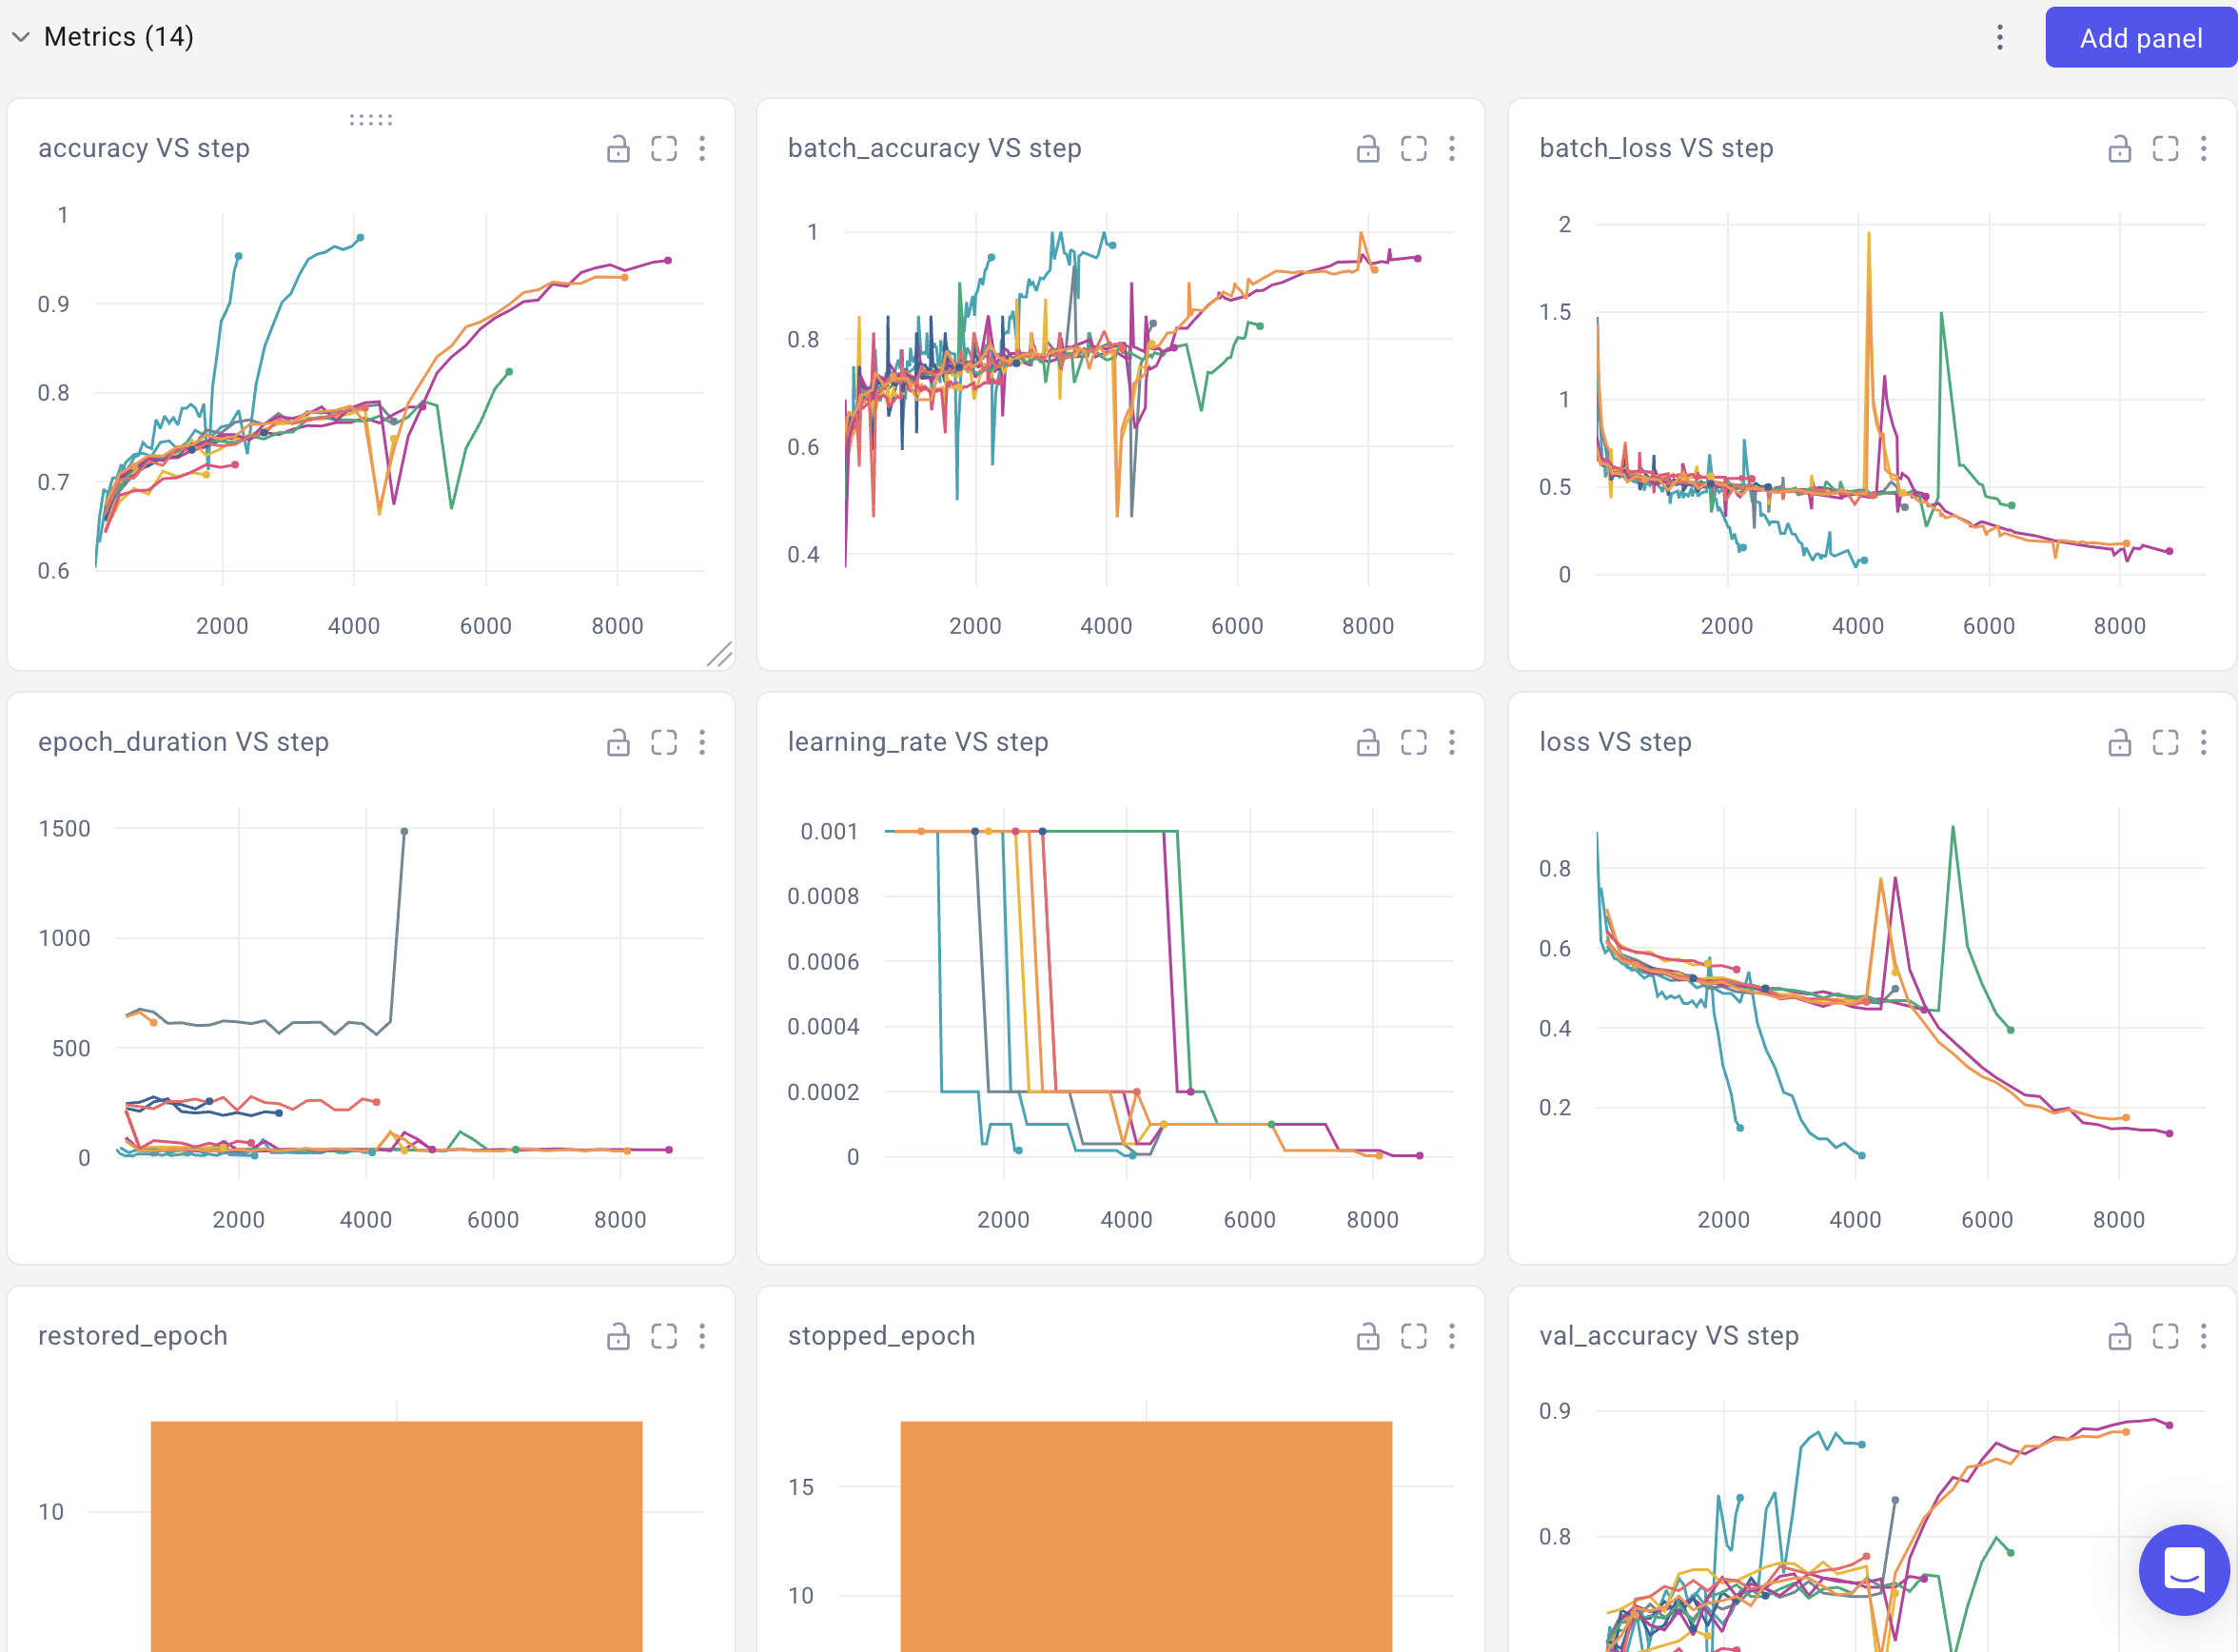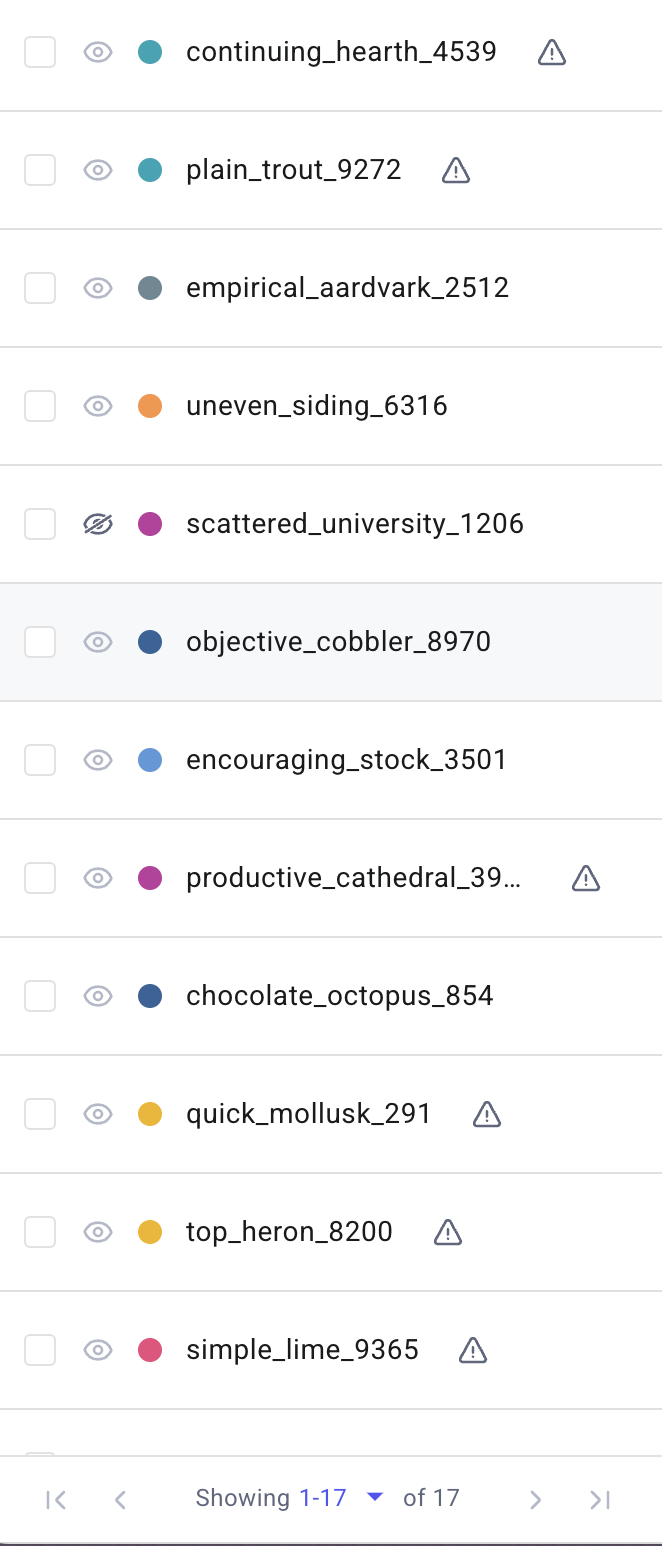

Ceci est à la fois utile pour de la visualisation de données mais également nous as permis maintes et maintes fois de couper un run d'un modèle qui nous décevait, ce qui explique certaines courbes qui s'arrêtent, où alors dans le cas des deux plus élevées, des modèles avec des itérations moins nombreuses mais nous y reviendrons plus tard.

Parmi ces données nous avons les plus importantes :

- La précision des résultats sur les données de test
- La perte de données sur les données de test
- La précision des résultats sur les données de validation
- La perte de données sur les données de validation
- La durée d'UN epoch
- Le learning rate (plus il réduit, avant le fine tuning) plus nous avons une perte de données


## Export du modèle

En effet, nous avions CometML pour nous permettre d'installer notre modèle, mais nous avons eu une idée que nous avons jugé plus "efficace" notamment pour notre API par la suite :

- Il existe un outil qui s'appelle HuggingFace qui répertorie plein de modèles mis au grand accès du public. Il s'agit à la fois d'un répertoire de modèles mais également d'un outil permettant de partager ses modèles au grand public.

Nous avons donc décidé de l'intégrer à notre modèle pour y déployer directement sur un répertoire nos modèles au fur et à mesure de ses améliorations

In [ ]:
import huggingface_hub

# Étape différente

huggingface_hub.login(token=userdata.get('HF_TOKEN'))

repo_id = "Loule/face-classification"

branch_name = experiment.id

# Étape différente

huggingface_hub.create_branch(repo_id=repo_id, branch=branch_name)
print(f"Branch '{branch_name}' created successfully. https://huggingface.co/{repo_id}/tree/{branch_name}")

# Étape différente

huggingface_hub.upload_file(
    path_or_fileobj=model_path,
    path_in_repo=model_path,
    repo_id=repo_id,
    commit_message="Upload best model",
    revision=branch_name
)

print(f"Model uploaded to Hugging Face Hub : https://huggingface.co/{repo_id}")


# Sauvegarder le modèle
model_path = "fine_tuned_face_classifier_model.keras"
model.save(model_path)

# Optionnel : Enregistrement du modèle dans Comet
experiment.log_model("fine_tuned_model", "fine_tuned_face_classifier_model.keras")

huggingface_hub.upload_file(
    path_or_fileobj=model_path,
    path_in_repo=model_path,
    repo_id=repo_id,
    commit_message="Upload fine-tuned model",
    revision=branch_name
)

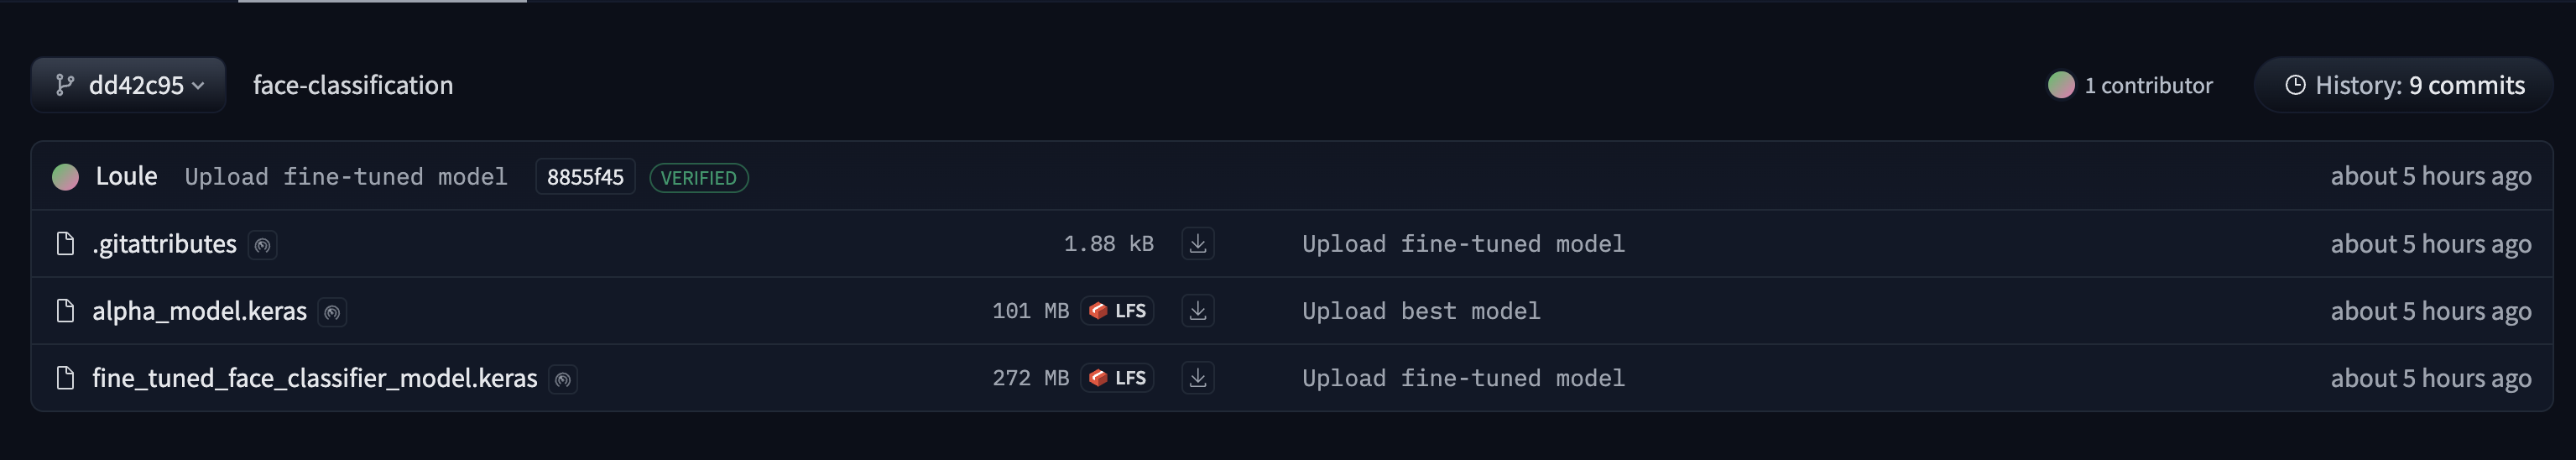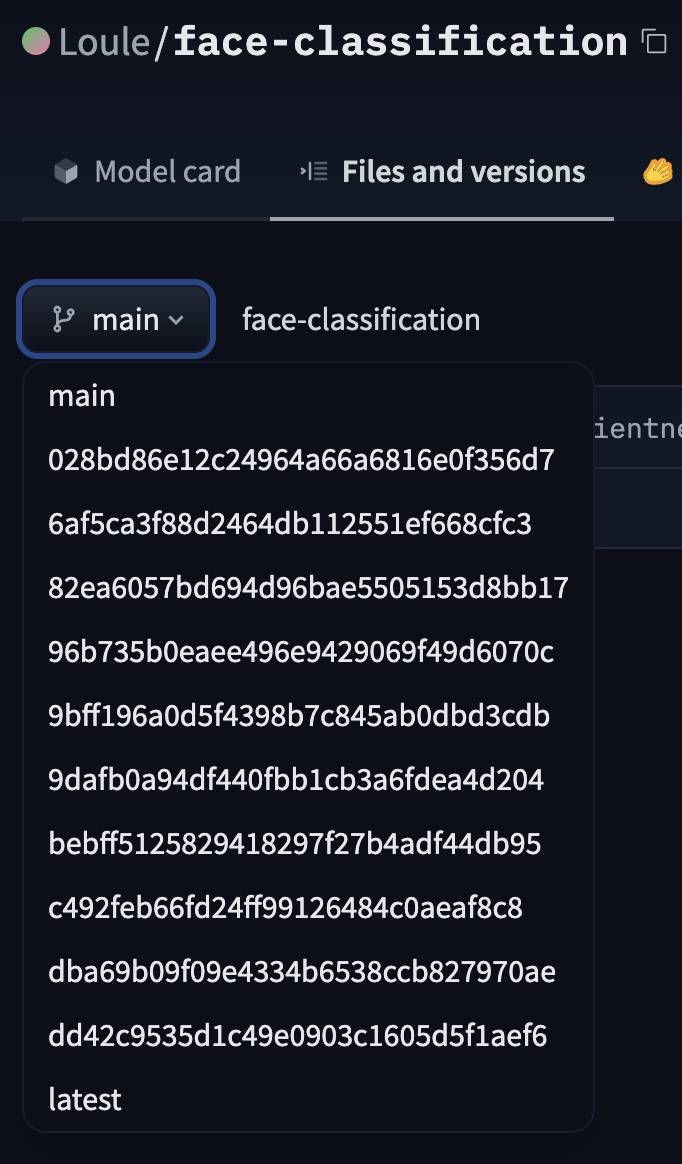

## Processus de tests avancés

Une chose qui a été développée assez tôt dans le projet a été l'ajout de processus de test avancés via le modèle avant toute intégration sur l'API voire même en production.

In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input

# Prédire si l'image est réelle ou fake
def predict_image(image, model):
    """Prédire si l'image est réelle ou fake."""
    image_preprocessed = preprocess_input(np.expand_dims(image, axis=0))
    prediction = model.predict(image_preprocessed)
    predicted_label = "Real" if prediction[0][0] <= 0.5 else "Fake"
    return predicted_label, prediction[0][0]

# Choisir une image fake aléatoire afin de la prédire
def choose_random_fake_image(fake_dir, model):
    all_files = [
        os.path.join(root, filename)
        for root, _, files in os.walk(fake_dir)
        for filename in files
        if filename.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]
    if not all_files:
        print("Aucune image fake trouvée.")
        return
    random_image_path = random.choice(all_files)
    img = tf.keras.preprocessing.image.load_img(random_image_path, target_size=(128, 128))
    img_array = tf.keras.preprocessing.image.img_to_array(img)

    # Prédiction du modèle
    predicted_label, prediction_score = predict_image(img_array, model)

    img.show()
    print(f"Image fake choisie : {random_image_path}")
    print(f"Prédiction du modèle pour image fake : {predicted_label} ({prediction_score:.2f})")


    # Choisir une image réelle aléatoire afin de la prédire
def choose_random_real_image(real_dir, model):
    all_files = [
        os.path.join(root, filename)
        for root, _, files in os.walk(real_dir)
        for filename in files
        if filename.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]
    if not all_files:
        print("Aucune image réelle trouvée.")
        return
    random_image_path = random.choice(all_files)
    img = load_img(random_image_path, target_size=(128, 128))
    img_array = img_to_array(img)

    # Prédiction du modèle
    predicted_label, prediction_score = predict_image(img_array, model)

    img.show()
    print(f"Image réelle choisie : {random_image_path}")
    print(f"Prédiction du modèle pour image réelle : {predicted_label} ({prediction_score:.2f})")


choose_random_real_image(REAL_FACES_DIR, model)
choose_random_fake_image(FAKE_FACES_DIR, model)


Alors il est évident que ce ne sont pas des choses qui étaient nécessaires surtout si on considère le développement de la fonction `predict_image` qui est un équivalent de la fonction predict déjà existante et qu'il s'agit d'une reproduction plutôt claire des comportements des training.

Mais cela nous as permis de tester plusieurs dizaines d'images

Notamment avec ce dérivé de fonction ci-dessous

In [ ]:
def evaluate_images(directory, model, label_expected, num_images=100):
    """
    Evaluate a set of images and calculate the percentage of predictions matching the expected label.

    :param directory: Directory containing the images to evaluate.
    :param model: The trained model.
    :param label_expected: 0 for "real", 1 for "fake".
    :param num_images: Number of images to test.
    :return: Percentage of predictions matching the expected label.
    """
    all_files = [
        os.path.join(root, filename)
        for root, _, files in os.walk(directory)
        for filename in files
        if filename.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]
    if len(all_files) < num_images:
        print(f"Not enough images in {directory}. Found only {len(all_files)} images.")
        num_images = len(all_files)

    sampled_files = random.sample(all_files, num_images)
    correct_predictions = 0

    for filepath in sampled_files:
        try:
            img = tf.keras.preprocessing.image.load_img(filepath, target_size=(128, 128))
            img_array = tf.keras.preprocessing.image.img_to_array(img)
            _, prediction_score = predict_image(img_array, model)
            predicted_label = 0 if prediction_score <= 0.5 else 1
            if predicted_label == label_expected:
                correct_predictions += 1
        except Exception as e:
            print(f"Error processing image {filepath}: {e}")

    percentage_correct = (correct_predictions / num_images) * 100
    return percentage_correct

real_percentage = evaluate_images(REAL_FACES_DIR, model, label_expected=0, num_images=1000)
fake_percentage = evaluate_images(FAKE_FACES_DIR, model, label_expected=1, num_images=1000)

print(f"Percentile of 'Real' predictions for {num_images} real images: {real_percentage:.2f}%")
print(f"Percentile of 'Fake' predictions for {num_images} fake images: {fake_percentage:.2f}%")

Ainsi, avec plusieurs modifications de ce code et adaptations, nous avons pu vérifier beaucoup de fois nos modèles, par exemple, le dernier en date que je vous ai montré dans ce notebook a eu ces résultats suivants :

- 1-ère occurence
  - Percentile of 'Real' predictions for 100 real images: 88.30%
  - Percentile of 'Fake' predictions for 100 fake images: 88.30%

- 2-ème occurence
  - Percentile of 'Real' predictions for 1000 real images: 90.80%
  - Percentile of 'Fake' predictions for 1000 fake images: 89.40%

- 3-ème occurence
  - Percentile of 'Real' predictions for 1000 real images: 87.70%
  - Percentile of 'Fake' predictions for 1000 fake images: 86.70%

- 4-ème occurence
  - Percentile of 'Real' predictions for 1000 real images: 88.60%
  - Percentile of 'Fake' predictions for 1000 fake images: 89.20%

- 5-ème occurence
  - Percentile of 'Real' predictions for 1000 real images: 89.10%
  - Percentile of 'Fake' predictions for 1000 fake images: 89.90%

- 6-ème occurence

  - Overall Percentile of 'Real' predictions for 1000 real images: 90.70%
  - Overall Percentile of 'Fake' predictions for 1000 fake images: 90.40%


Lors des tests, il s'agissait surtout de se conforter sur le modèle, de vérifier qu'il était stable et surtout d'être sûr de ne pas avoir un modèle qui est faillible à plus de 15% qui rendraient sa mise en production presque "inutile" par rapport à son apprentissage.

Néanmoins il faut se dire que les tests par-dessus ont été exécuté il y a quelques jours de cela, et que certaines versions ont été testées en production dont des versions qui battraient celle là mais nous gardons nos résultats en guise d'étude.

# ÉCHECS

## Évolution du modèle sur sa version récente

Un problème que nous avons rencontré qui nous as pas mal déçu est lorsque nous avons tenté de passer sur un modèle plus récent.

Pour une remise en contexte nous utilisons le modèle pré-entrainé EfficientNetB0, mais il faut savoir que sa famille EfficientNetB contient 8 versions dont la plus récente EfficientNetB7

Pour l'optimisation nous avons donc tenté d'évoluer le modèle vers EfficientNetB7 mais nous avons alors observé ceci

In [ ]:
from tensorflow.keras.applications import EfficientNetB7

# Création du modèle
def build_model():
    base_model = EfficientNetB7(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
    base_model.trainable = False

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer=parameters["optimizer"], loss=parameters["loss"], metrics=['accuracy'])
    return model

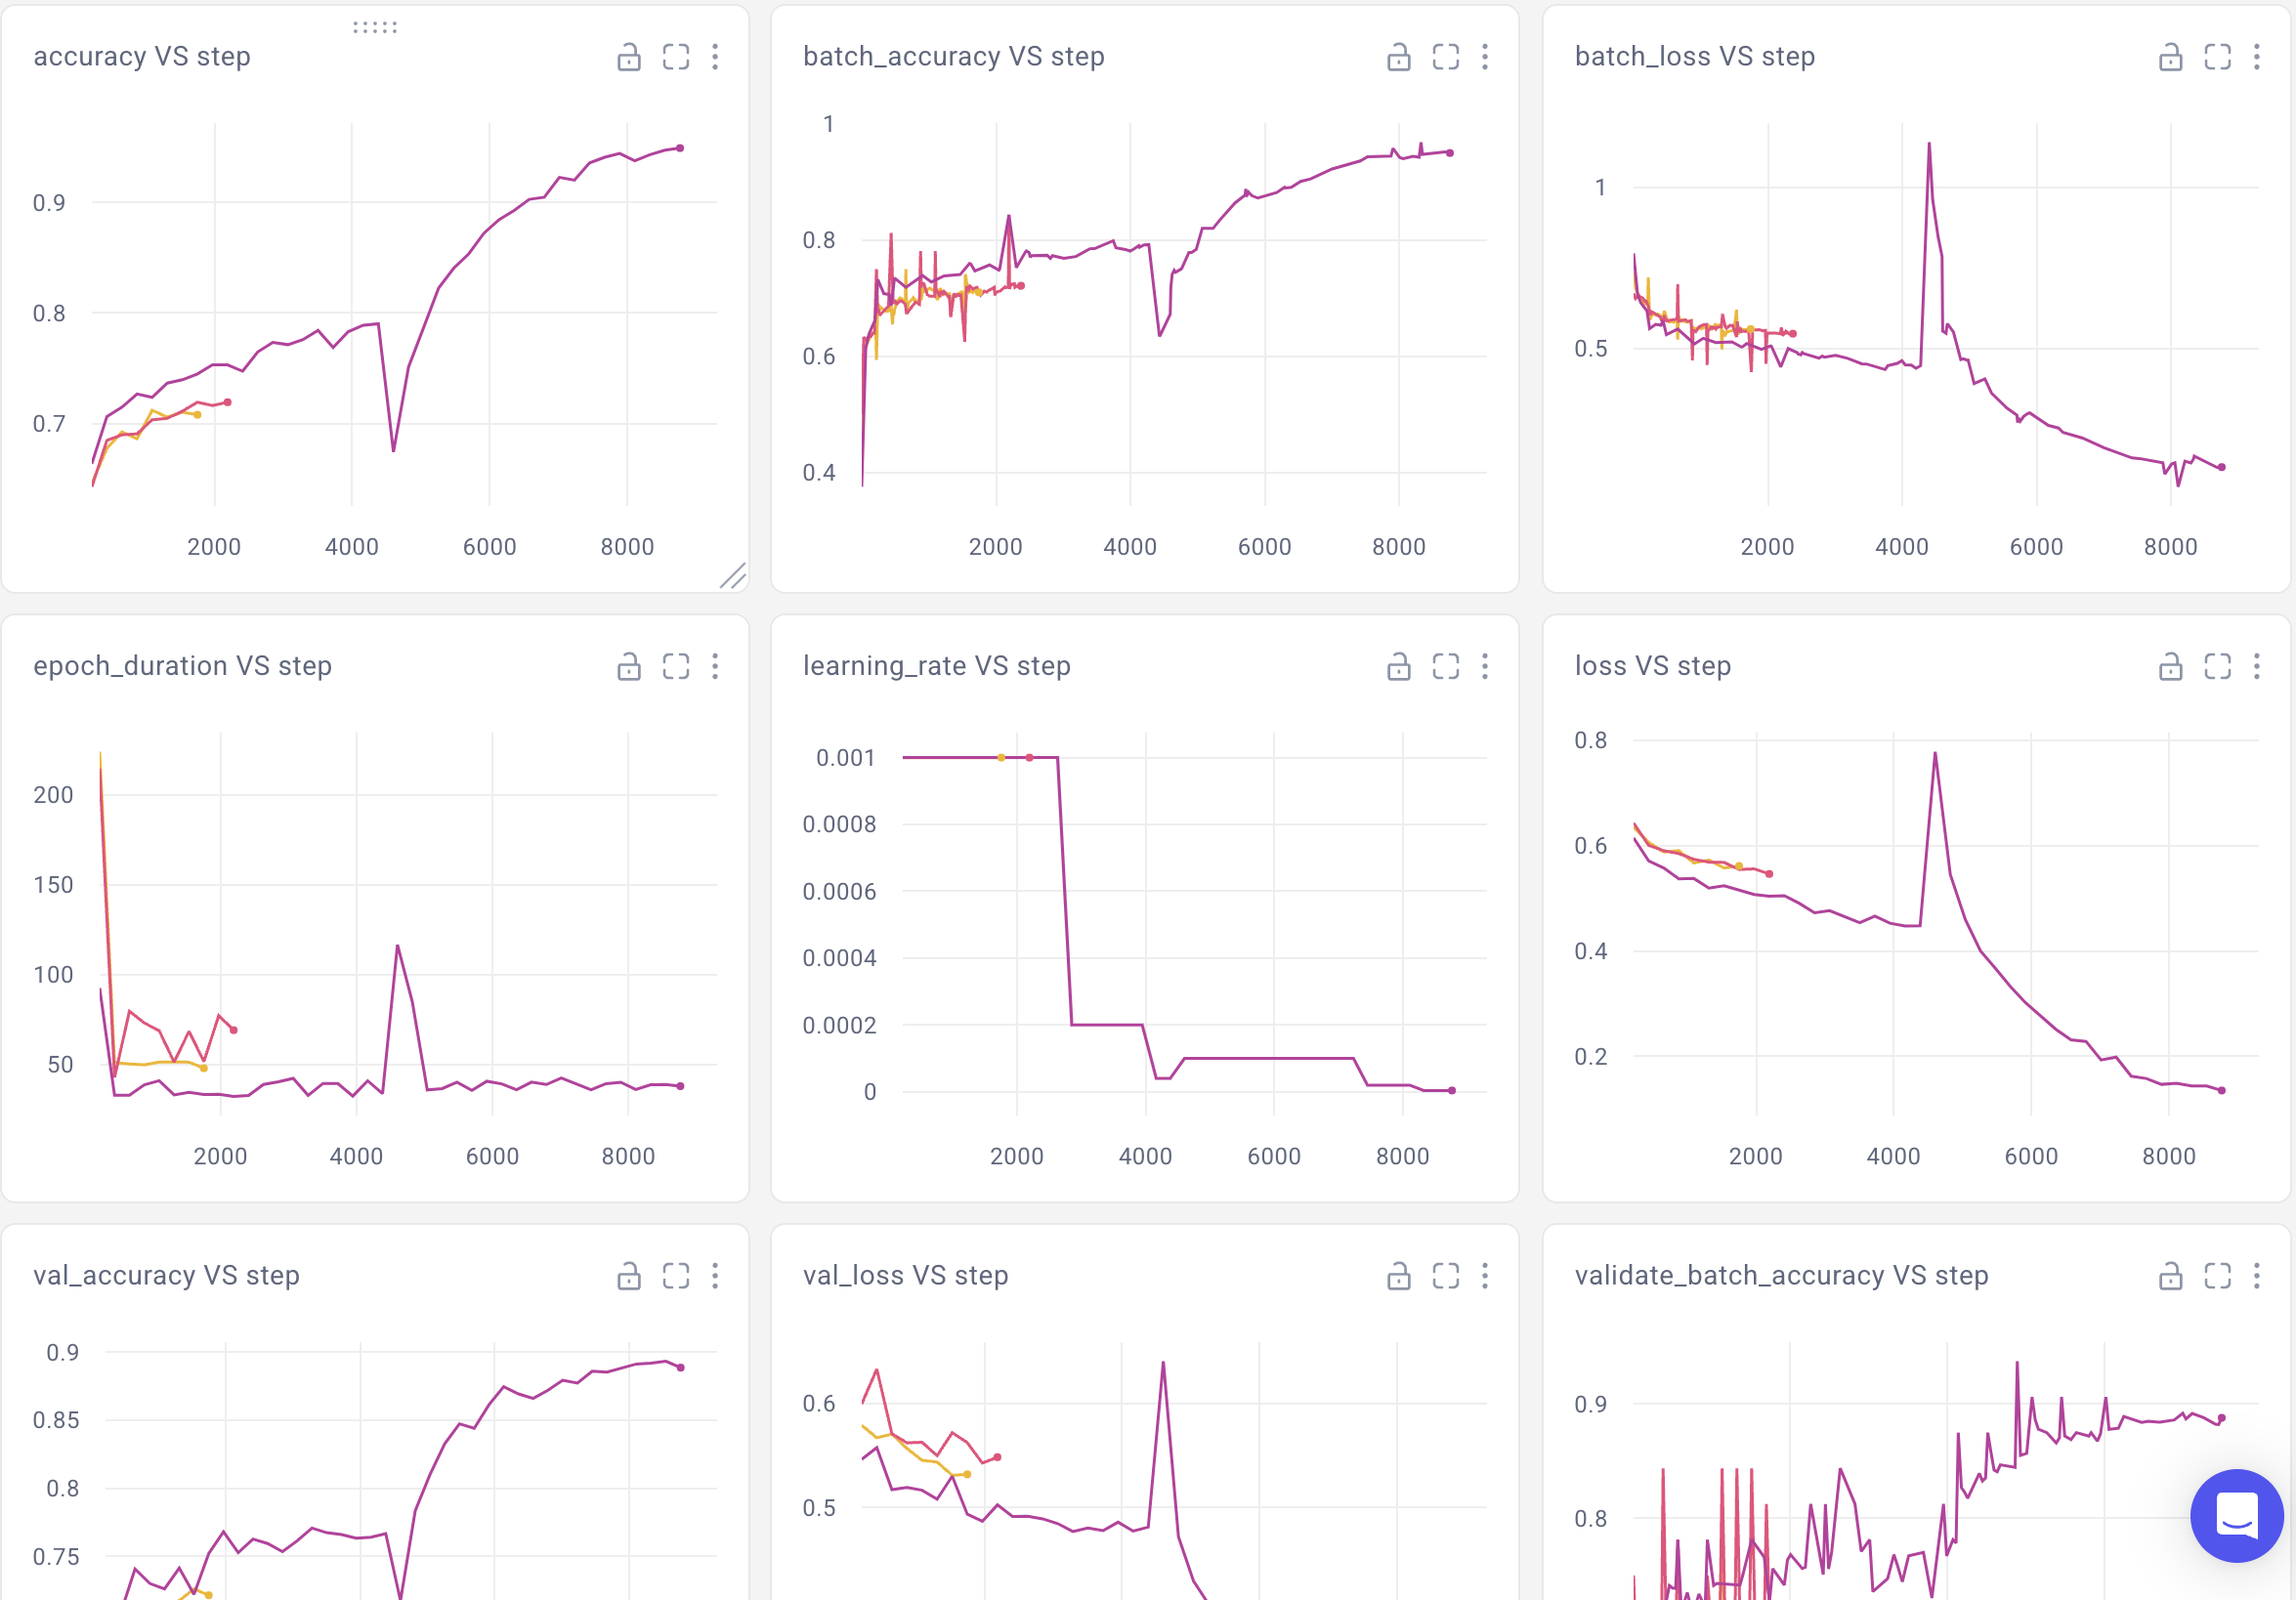

On peut observer assez facilement certaisn problèmes, Ici en violet, notre meilleur modèle EfficientNetB0, en rouge et orange, les deux modèles qu'on a essayé de faire fonctionner en EfficientNetB7.

On remarque assez facilement que les deux modèles sont pires que le premier, et ça dans tous les points, le modèle était de base plus lour et provoquait alors une surcharge sur notre CPU et notre GPU et venait donc ralentir notre modèle, le rendant plus faible, plus fragile et de ce fait moins efficace. Si on y rajoute le temps d'exécution de ce fait beaucoup plus long, on remarque alors que ces modèles ne sont pas du tout viables.

C'est un échec dans le sens où nous n'avons pas pu améliorer le modèle de la manière dont on le souhaitait. Cela nous as certes ralenti mais nous avons néanmoins essayé d'y palier

## Intégration de la GRAD-CAM

Une autre raison pour laquelle nous avons souhaité changer de modèle entre B0 et B7 c'est que nous avons observé une mauvaise nouvelle.

Avec EfficientNetB0, il semblait compliqué voir impossible d'y intégrer une GRAD-CAM, c'est à dire globalement une preuve visuelle (via une heat-map) de ce qui rendait une image fausse. Nous pensions pouvoir l'intégrer via B7, mais l'incapacité du modèle rend son intégration quasi-impossible.

Ce qui le rend impossible c'est que la couche supérieure devant soutenir la grad-cam ne la supportait pas, de ce fait lorsque nous étions de faire une grad-cam, cela plantait et ne fonctionnait pas

`error: 'Grad-CAM and Grad-CAM++ failed to generate heatmap.'

Une potentielle solution que nous sommes entrain d'expérimenter est le changement de modèle. Mais nous allons en parler tout de suite après.

## Critique des données

Un problème par rapport aux données qu'on utilise sont qu'elles sont temporellement assez anciennes par rapport à l'évolution des modèles d'Intelligence Artificielle Génératifs.

De ce fait, en plus de réduire la précision de notre modèle, on a un biais assez nocif qui est que un modèle comme Grok 2, sorti en fin 2025 est capable de tromper notre modèle et de crédibiliser une image qu'il a généré lui même.
C'est un danger autant sur le fait éthique que sur un plan beaucoup plus global car si notre modèle venait à être utilisé comme argent comptant, et qu'on identifiait un biais de confirmation parce que notre IA ressort un taux faible de fausseté, et bien en réalité on pourrait avoir une manipulation plus globale de la foule.

Ce modèle devient donc dangereux, risquant d'être utilisé comme outil de détournement et de ce fait si on devait entraîner ce modèle, il faudrait une adaptation des données presque journalière pour suivre la cadence d'évolution des IA génératives.

# CHANGEMENT DRASTIQUE ?


Un changement de modèle s'impose, et qu'est-ce qu'il donne ce changement de modèle ?

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50

parameters = {
    "batch_size": 128,
    "epochs": 50,
    "optimizer": "adam",
    "loss": "binary_crossentropy",
    "validation_split": 0.1,
}

experiment.log_parameters(parameters)

# Création du modèle
def build_model():
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
    base_model.trainable = False

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer=parameters["optimizer"], loss=parameters["loss"], metrics=['accuracy'])
    return model

Pourquoi utiliser [ResNet50](https://keras.io/api/applications/resnet/) ?

La question se pose évidemment. Notre modèle fonctionne très bien et pourtant nous ne sommes pas satisfait. Pas satisfait de ne pas pouvoir intégrer une preuve visuelle que l'image fournie est très probablement fausse. Donc oui c'est un changement risqué mais c'est un changement qui vaut le coup d'être tenté.

Et certains résultats nous prouvent qu'on a peut-être raison.

Autrement que d'avoir tenté d'intégrer la Grad-Map, en réalité on a surtout un écart de performances.

Le modèle est plus lourd certes mais il a l'air plus complet, plus adapté à nos recherches. Il est plus lourd certes mais se concentre d'autant plus sur les tâches les plus complexes. Et même si nous devons alors réduire nos quantités de données pour avoir un temps d'exécution similaire pour les deux modèles nous pouvons alors comparer les résultats.

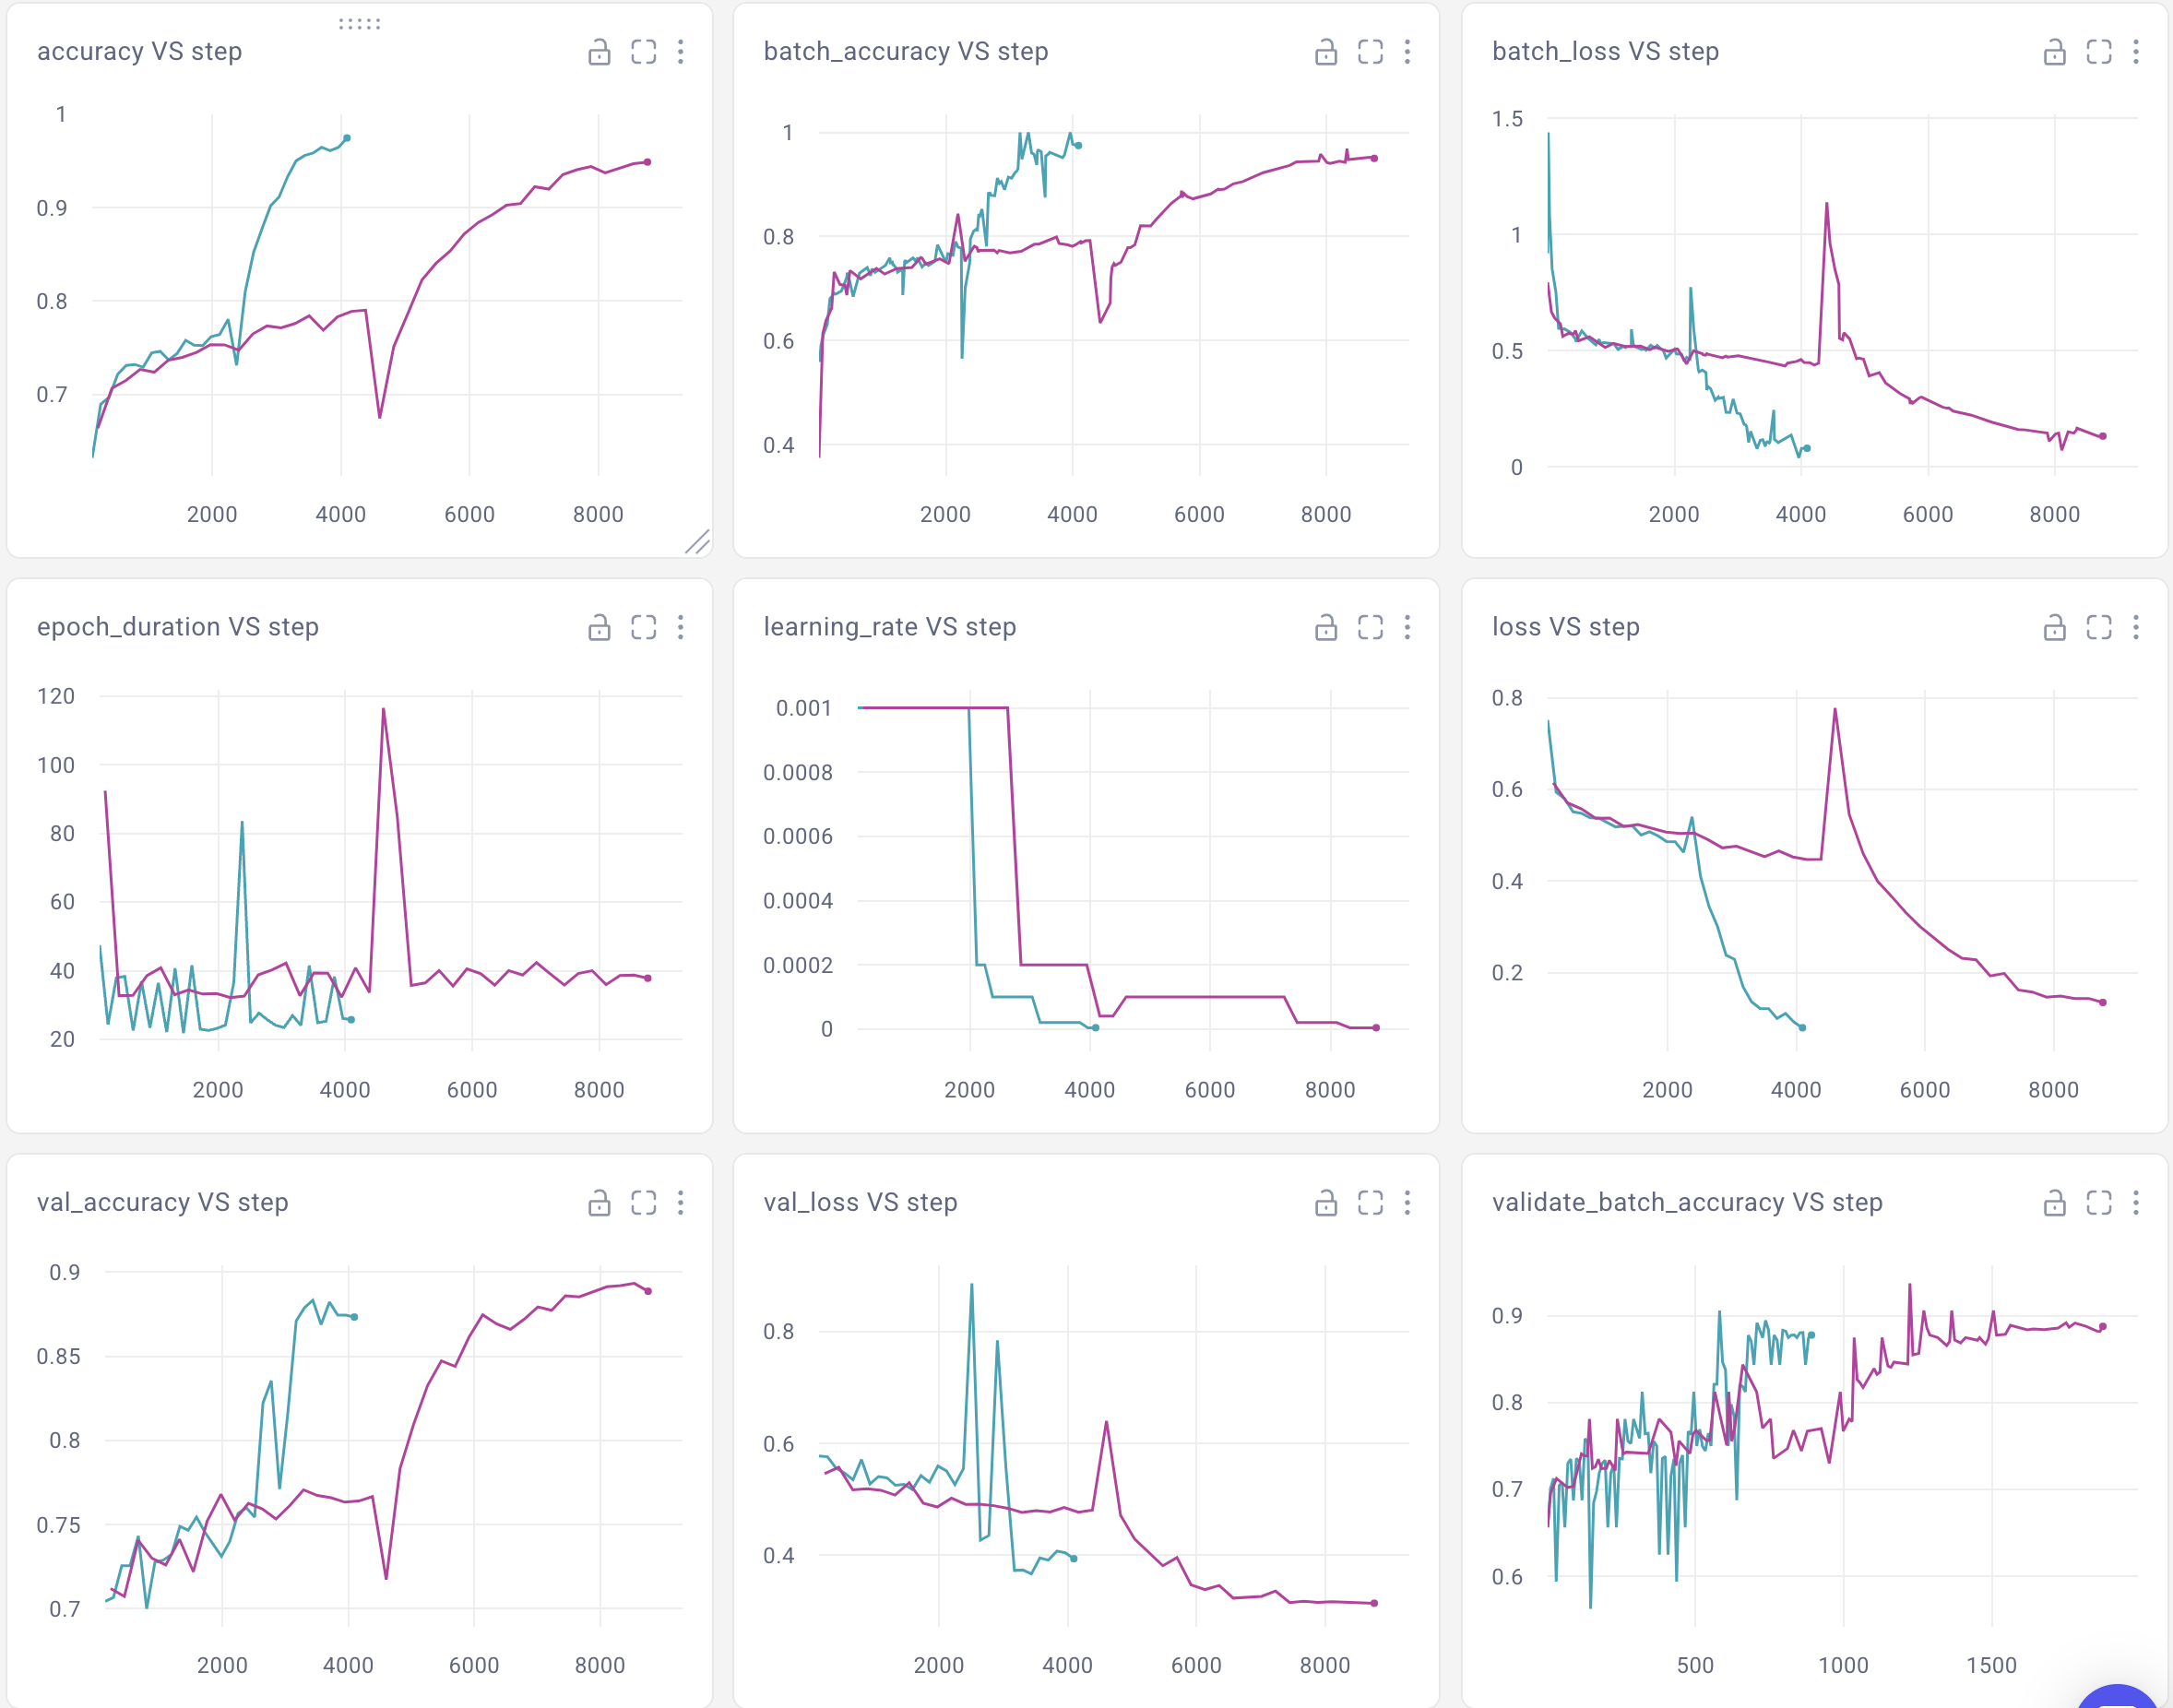

Nous avons des résultats similaires pour deux voire même meilleurs pour la plupart.Cependant c'est plus dangereux, nous avons des variations de pertes sur les données de Validation qui sont inquiétantes mais une accuracy globalement plus haute et plus vite.

Encore une fois c'est un risque, mais le risque semble assez léger si on considère les valeurs qu'on peut voir pour moins de données. Il s'agit certes d'un risque à prendre mais si il paie il nous permettrait peut-être d'intégrer une Grad-Map, dans le cas échéant, il sera peut-être plus fiable de retourner sur l'ancien modèle.

Après plusieurs essais après mise en production, il s'avère que le modèle ne fonctionne pas, il a un surapprentissage beaucoup trop violent et est très mauvais dans les cas de production et n'identifie aucun faux visage sauf si il est évident.

Il s'agit donc d'un échec, et qui montre l'effet dur surapprentissage mais d'un impact beaucoup plus violent que les anciens modèles, car ici aucune photo n'est identifiée comme fausse lorsqu'on sait qu'elles le sont dans des données de production.

Nous avons également testé **InceptionV3** et **DenseNet121** pour la classification d’images. InceptionV3, avec sa structure modulaire basée sur des blocs *Inception*, est conçu pour optimiser les calculs tout en augmentant la profondeur et la largeur du réseau. DenseNet121, de son côté, repose sur des connexions denses entre les couches pour mieux réutiliser les informations extraites. Malgré leur conception avancée, ces modèles ont donné des résultats très décevants, avec une précision d’apprentissage qui est restée en dessous de 50 %, ce qui les rendait inadaptés à notre projet.

Nous avons aussi essayé les modèles **EfficientNetB4**, **B5** et **B7**, des versions plus grandes et plus précises de la famille EfficientNet. Grâce à leur stratégie d’optimisation, ils offrent une efficacité impressionnante. Cependant, ces modèles nécessitent énormément de ressources, et les temps de compilation étaient beaucoup trop longs pour nos contraintes, malgré des performances clairement meilleures.

# VERSION FINALE DU CODE

La version finale du modèle n'est pas présente copiée collée ici car en constante évolution, mais néanmoins un lien pour y accéder est [celui-ci](https://colab.research.google.com/drive/1jIjLLTK4IEWmn6ozpuEs6J2etUFTYt3v?usp=sharing)

# DOCUMENTATION

Nos sets de données

- [Training Real](https://www.kaggle.com/datasets/tunguz/70000-real-faces-1)
- [Training Fake](https://www.kaggle.com/datasets/tunguz/1-million-fake-faces)
- [Inspiration Fakes Production](https://thispersondoesnotexist.com/)


Voici les liens qui ont permis de nous aider sur ce sujet, le lien vers les forums ou les inspirations pour la création du modèle et son évolution

- [Adam Optimizer](https://www.ultralytics.com/fr/glossary/adam-optimizer)
- [EfficientNetB0](https://medium.com/image-processing-with-python/efficientnetb0-architecture-stem-layer-496c7911a62d)
- [EfficientNet](https://keras.io/api/applications/efficientnet/)
- [Image Classification](https://keras.io/examples/vision/image_classification_from_scratch/)
- [Conv2D Layer](https://keras.io/api/layers/convolution_layers/convolution2d/)
- [Sequential Model](https://www.tensorflow.org/guide/keras/sequential_model?hl=fr)